In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set publication-quality styling
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['savefig.dpi'] = 300 # High resolution for the research paper      

In [ ]:
# 1. Load k6 Latency Data
try:
    df_pandas_k6 = pd.read_csv('../data/reports/pandas_latency.csv')
    df_polars_k6 = pd.read_csv('../data/reports/polars_latency.csv')
    
    # Filter only the HTTP request duration metric
    pandas_latency = df_pandas_k6[df_pandas_k6['metric_name'] == 'http_req_duration']['metric_value']
    polars_latency = df_polars_k6[df_polars_k6['metric_name'] == 'http_req_duration']['metric_value']
    print(f"Loaded {len(pandas_latency)} Pandas requests and {len(polars_latency)} Polars requests.")
except FileNotFoundError:
    print("Warning: k6 CSV files not found. Ensure you ran the load tests.")

# 2. Load Docker Resource Data
# 2. Load Docker Resource Data
try:
    df_pd_res_raw = pd.read_csv('../data/reports/pandas_resources.csv')
    df_pl_res_raw = pd.read_csv('../data/reports/polars_resources.csv')
    
    df_pd_res_raw['timestamp'] = pd.to_datetime(df_pd_res_raw['timestamp'])
    df_pl_res_raw['timestamp'] = pd.to_datetime(df_pl_res_raw['timestamp'])
    
    print(f"Loaded resource data: {len(df_pd_res_raw)} Pandas points, {len(df_pl_res_raw)} Polars points.")
except FileNotFoundError:
    print("Warning: Resource monitoring CSVs not found.")

Loaded 1080 Pandas requests and 2050 Polars requests.
Loaded resource data: 30 Pandas points, 30 Polars points.


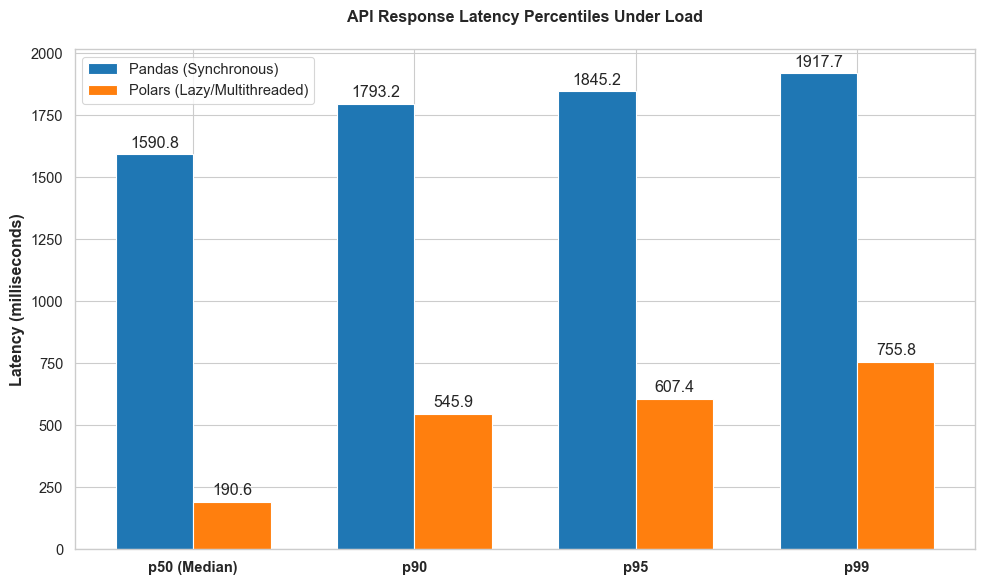

In [30]:
# Calculate percentiles
percentiles = [0.50, 0.90, 0.95, 0.99]
labels = ['p50 (Median)', 'p90', 'p95', 'p99']

pandas_stats = pandas_latency.quantile(percentiles).values
polars_stats = polars_latency.quantile(percentiles).values

# Set up the bar chart
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, pandas_stats, width, label='Pandas (Synchronous)', color='#1f77b4')
rects2 = ax.bar(x + width/2, polars_stats, width, label='Polars (Lazy/Multithreaded)', color='#ff7f0e')

# Add labels, title, and formatting
ax.set_ylabel('Latency (milliseconds)', fontweight='bold')
ax.set_title('API Response Latency Percentiles Under Load', pad=20, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontweight='bold')
ax.legend()

# Auto-label the bars with their exact values
ax.bar_label(rects1, padding=3, fmt='%.1f')
ax.bar_label(rects2, padding=3, fmt='%.1f')

plt.tight_layout()
plt.savefig('../data/reports/fig1_latency_comparison.png')
plt.show()

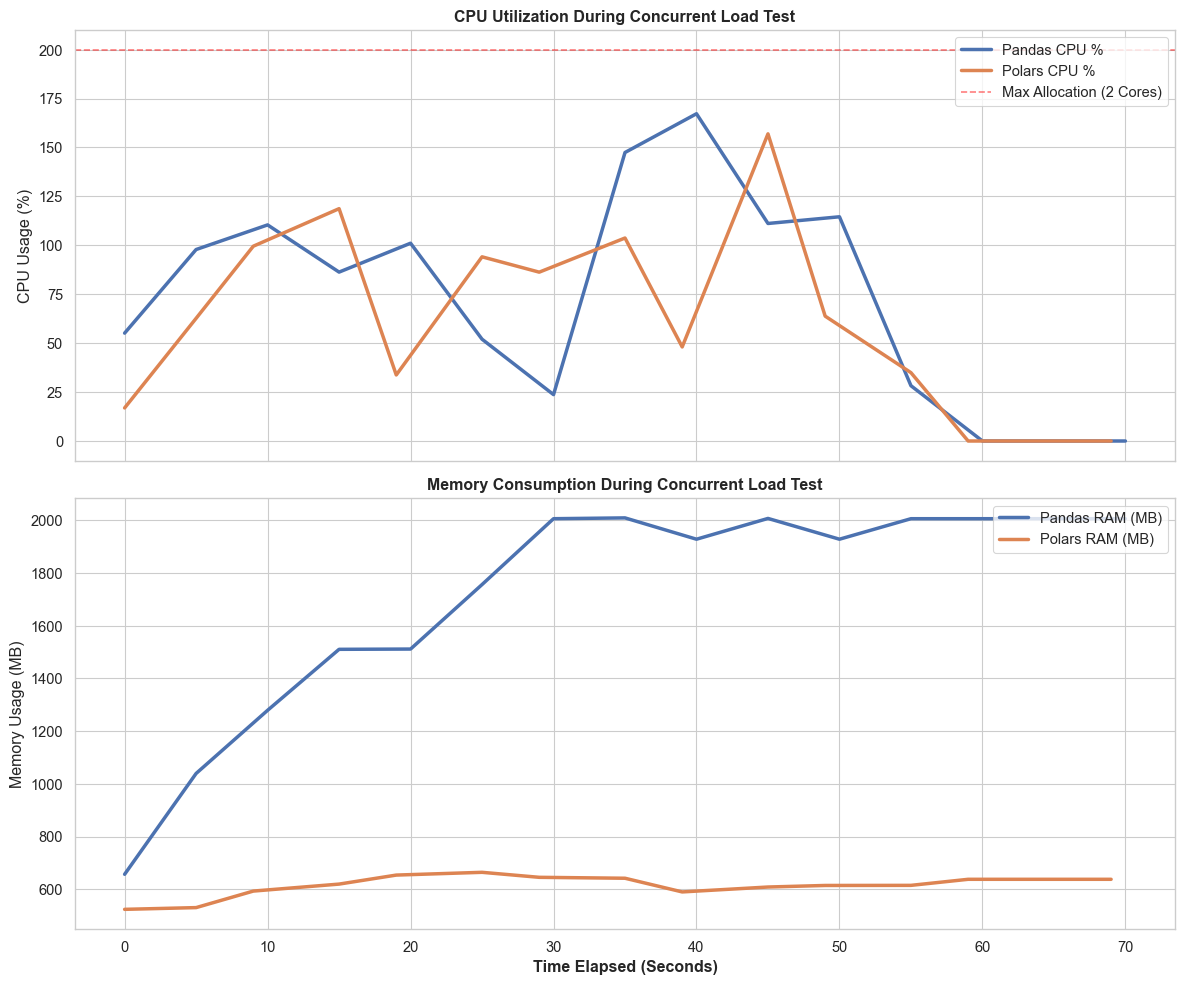

In [31]:
# Create a figure with two subplots (CPU on top, Memory on bottom)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Define exact container names from the script
pandas_container = "benchmark-pandas"
polars_container = "benchmark-polars"

# Filter data per container
# df_pd_res = df_resources[df_resources['container'] == pandas_container].copy()
# df_pl_res = df_resources[df_resources['container'] == polars_container].copy()
# ... (keep the fig setup)

# Filter the raw data to ONLY include the active container for that specific test run
df_pd_res = df_pd_res_raw[df_pd_res_raw['container'] == "benchmark-pandas"].copy()
df_pl_res = df_pl_res_raw[df_pl_res_raw['container'] == "benchmark-polars"].copy()

# Normalize timestamps so they both start at T=0 seconds
if not df_pd_res.empty and not df_pl_res.empty:
    start_time_pd = df_pd_res['timestamp'].min()
    start_time_pl = df_pl_res['timestamp'].min()
    
    df_pd_res['seconds_elapsed'] = (df_pd_res['timestamp'] - start_time_pd).dt.total_seconds()
    df_pl_res['seconds_elapsed'] = (df_pl_res['timestamp'] - start_time_pl).dt.total_seconds()

    # --- Plot 1: CPU Utilization ---
    sns.lineplot(data=df_pd_res, x='seconds_elapsed', y='cpu_percent', ax=ax1, label='Pandas CPU %', linewidth=2.5)
    sns.lineplot(data=df_pl_res, x='seconds_elapsed', y='cpu_percent', ax=ax1, label='Polars CPU %', linewidth=2.5)
    
    ax1.set_title('CPU Utilization During Concurrent Load Test', fontweight='bold')
    ax1.set_ylabel('CPU Usage (%)')
    ax1.axhline(200, ls='--', color='red', alpha=0.5, label='Max Allocation (2 Cores)') # Assuming 2.0 CPUs in docker-compose
    ax1.legend(loc='upper right')

    # --- Plot 2: Memory Consumption ---
    sns.lineplot(data=df_pd_res, x='seconds_elapsed', y='memory_mb', ax=ax2, label='Pandas RAM (MB)', linewidth=2.5)
    sns.lineplot(data=df_pl_res, x='seconds_elapsed', y='memory_mb', ax=ax2, label='Polars RAM (MB)', linewidth=2.5)
    
    ax2.set_title('Memory Consumption During Concurrent Load Test', fontweight='bold')
    ax2.set_xlabel('Time Elapsed (Seconds)', fontweight='bold')
    ax2.set_ylabel('Memory Usage (MB)')
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.savefig('../data/reports/fig2_resource_utilization.png')
    plt.show()
else:
    print("Not enough resource data to plot.")

In [ ]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import os

# Set publication-quality styling
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['savefig.dpi'] = 300 

def load_k6_latency(filepath):
    """Safely loads and extracts percentiles from a k6 JSON summary."""
    try:
        with open(filepath, 'r') as f:
            data = json.load(f)
            m = data['metrics']['http_req_duration']['values']
            return [m['med'], m['p(90)'], m['p(95)'], m['p(99)']]
    except FileNotFoundError:
        print(f"Warning: {filepath} not found.")
        return [0, 0, 0, 0]
    except KeyError as e:
        print(f"Warning: Unexpected JSON structure in {filepath}. Error: {e}")
        return [0, 0, 0, 0]

def load_resource_data(filepath):
    """Safely loads CSV resource data and normalizes the timestamps."""
    try:
        df = pd.read_csv(filepath)
        if df.empty:
            return df
            
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        start_time = df['timestamp'].min()
        df['seconds_elapsed'] = (df['timestamp'] - start_time).dt.total_seconds()
        return df
    except FileNotFoundError:
        print(f"Warning: {filepath} not found.")
        return pd.DataFrame()

def plot_operation_metrics(operation: str):
    """
    Reads the 4 specific files for a given operation and generates 
    the Latency Bar Chart and the Resource Utilization Line Charts.
    """
    print(f"--- Generating Reports for Operation: {operation.upper()} ---")
    
    # Define file paths based on the operation argument
    base_dir = '../data/reports'
    os.makedirs(base_dir, exist_ok=True)
    
    json_pd = os.path.join(base_dir, f'pandas_{operation}.json')
    json_pl = os.path.join(base_dir, f'polars_{operation}.json')
    csv_pd = os.path.join(base_dir, f'pandas_{operation}_resources.csv')
    csv_pl = os.path.join(base_dir, f'polars_{operation}_resources.csv')

    # ==============================================================================
    # 1. PLOT LATENCY (Bar Chart)
    # ==============================================================================
    pandas_stats = load_k6_latency(json_pd)
    polars_stats = load_k6_latency(json_pl)

    labels = ['p50 (Median)', 'p90', 'p95', 'p99']
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, pandas_stats, width, label='Pandas (Sync)', color='#1f77b4')
    rects2 = ax.bar(x + width/2, polars_stats, width, label='Polars (Multithreaded)', color='#ff7f0e')

    ax.set_ylabel('Latency (milliseconds)', fontweight='bold')
    title_text = f'API Response Latency: {operation.replace("-", " ").title()}'
    ax.set_title(title_text, pad=20, fontweight='bold', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontweight='bold')
    ax.legend()

    # Auto-label the bars with their exact values
    ax.bar_label(rects1, padding=3, fmt='%.1f')
    ax.bar_label(rects2, padding=3, fmt='%.1f')

    plt.tight_layout()
    latency_out = os.path.join(base_dir, f'{operation}_latency.png')
    plt.savefig(latency_out)
    print(f"Saved Latency Chart: {latency_out}")
    plt.close()

    # ==============================================================================
    # 2. PLOT RESOURCES (CPU & Memory Line Charts)
    # ==============================================================================
    df_pd_res = load_resource_data(csv_pd)
    df_pl_res = load_resource_data(csv_pl)

    # Check if either dataframe has data before attempting to plot resources
    if not df_pd_res.empty or not df_pl_res.empty:
        fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
        fig2.suptitle(f'Resource Utilization: {operation.replace("-", " ").title()}', 
                      fontweight='bold', fontsize=14, y=0.98)

        # --- CPU Plot ---
        if not df_pd_res.empty:
            sns.lineplot(data=df_pd_res, x='seconds_elapsed', y='cpu_percent', ax=ax1, label='Pandas CPU %', linewidth=2.5)
        if not df_pl_res.empty:
            sns.lineplot(data=df_pl_res, x='seconds_elapsed', y='cpu_percent', ax=ax1, label='Polars CPU %', linewidth=2.5)
            
        ax1.set_ylabel('CPU Usage (%)')
        ax1.axhline(200, ls='--', color='red', alpha=0.5, label='Max Allocation (2 Cores)')
        ax1.legend(loc='upper right')

        # --- Memory Plot ---
        if not df_pd_res.empty:
            sns.lineplot(data=df_pd_res, x='seconds_elapsed', y='memory_mb', ax=ax2, label='Pandas RAM (MB)', linewidth=2.5)
        if not df_pl_res.empty:
            sns.lineplot(data=df_pl_res, x='seconds_elapsed', y='memory_mb', ax=ax2, label='Polars RAM (MB)', linewidth=2.5)
            
        ax2.set_xlabel('Time Elapsed (Seconds)', fontweight='bold')
        ax2.set_ylabel('Memory Usage (MB)')
        ax2.legend(loc='upper right')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        resources_out = os.path.join(base_dir, f'{operation}_resources.png')
        plt.savefig(resources_out)
        print(f"Saved Resource Chart: {resources_out}")
        plt.close()
    else:
        print(f"Skipping resource charts for '{operation}': No CSV data found.")

if __name__ == "__main__":
    # Grab the first argument, fallback to heavy-join if none is provided
    operation = sys.argv[1].lower() if len(sys.argv) > 1 else "heavy-join"
    plot_operation_metrics(operation)